In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('data_uotlier_treated.csv')


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3498 entries, 0 to 3497
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_name        3498 non-null   object 
 1   type                 3498 non-null   object 
 2   society              3111 non-null   object 
 3   sector               3498 non-null   object 
 4   price                3498 non-null   float64
 5   price_per_sqft       3498 non-null   float64
 6   area                 3498 non-null   float64
 7   areaWithType         3498 non-null   object 
 8   bedRoom              3498 non-null   int64  
 9   bathroom             3498 non-null   int64  
 10  balcony              3498 non-null   int64  
 11  address              3490 non-null   object 
 12  floorNum             3483 non-null   float64
 13  facing               3498 non-null   object 
 14  agePossession        3498 non-null   object 
 15  description          3498 non-null   o

In [9]:
df.isnull().sum()

property_name             0
type                      0
society                 387
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
address                   8
floorNum                 15
facing                    0
agePossession             0
description               0
super_built_up_area    1624
built_up_area          1961
carpet_area            1671
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

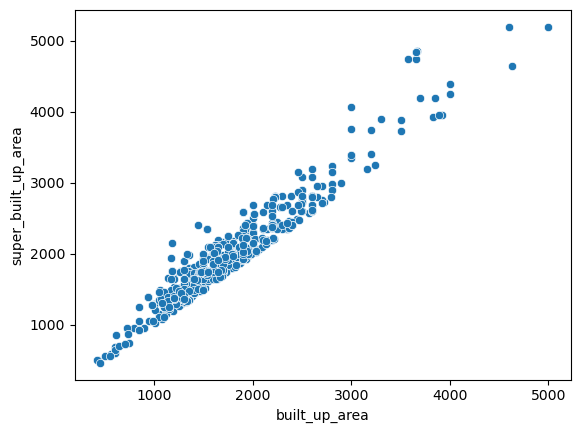

In [12]:
sns.scatterplot(x = df['built_up_area'],y = df['super_built_up_area'])

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

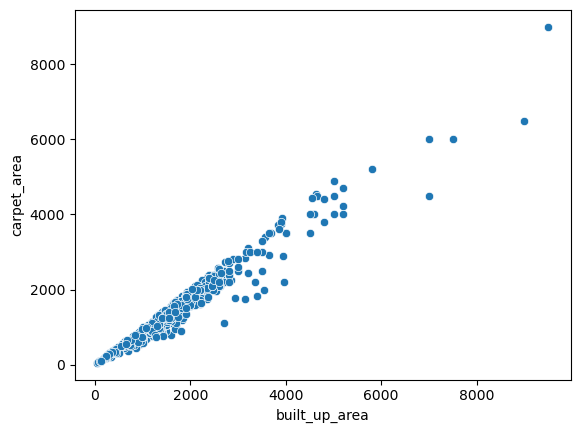

In [13]:
sns.scatterplot(x = df['built_up_area'],y =df['carpet_area'])

In [14]:
((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())).sum()

0

In [15]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [16]:
all_present_df.shape

(531, 26)

In [17]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [18]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [19]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.105263157894737 0.9


In [20]:
# both present built up null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [21]:
sbc_df.head()

,property_name,type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,address,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
4,2 BHK Flat in Sector 85 Gurgaon,flat,ss the leaf,sector 85,1.20,9677.0,1240.0,Super Built up area 1772(164.62 sq.m.)Carpet a...,2,2,3,"Tower 1, Sector 85 Gurgaon, Gurgaon, Haryana",9.0,East,Relatively New,Looking for a 2 bhk property for sale in gurga...,1772.0,NaN,1240.0,0,0,1,0,0,1,148
13,2 BHK Flat in Sector 70A Gurgaon,flat,paras irene,sector 70a,1.30,9220.0,1410.0,Super Built up area 1420(131.92 sq.m.)Carpet a...,2,2,3,"Sector 70A Gurgaon, Gurgaon, Haryana",19.0,DK,Moderately Old,2bhk in paras irene in very good condition,1420.0,NaN,1410.0,0,0,0,0,0,0,49
16,3 BHK Flat in Sector 108 Gurgaon,flat,experion the heartsong,sector 108,1.30,8344.0,1558.0,Super Built up area 1758(163.32 sq.m.)Carpet a...,3,3,3,"7th, Sector 108 Gurgaon, Gurgaon, Haryana",7.0,South-West,Relatively New,This 3 bhk apartment is available for sale in ...,1758.0,NaN,1558.0,1,0,0,0,0,1,150
20,3 BHK Flat in Sector 91 Gurgaon,flat,tarc maceo,sector 91,1.50,6466.0,2320.0,Super Built up area 2320(215.54 sq.m.)Carpet a...,3,4,3,"Sector 91 Gurgaon, Gurgaon, Haryana",3.0,North-West,Relatively New,This 3 bhk apartment is available for sale in ...,2320.0,NaN,1325.0,1,1,0,0,0,1,112
26,3 BHK Flat in Sector 81 Gurgaon,flat,dlf the ultima,sector 81,2.35,11233.0,2092.0,Super Built up area 2092(194.35 sq.m.)Carpet a...,3,4,3,"125, Sector 81 Gurgaon, Gurgaon, Haryana",18.0,North,Relatively New,Dlf the ultima is one of gurgaon's most sought...,2092.0,NaN,1100.0,0,1,0,0,0,1,106


In [22]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_26016\1215074969.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_26016\1215074969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-co

In [23]:
df.update(sbc_df)

In [24]:
df.isnull().sum()

property_name             0
type                      0
society                 387
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
address                   8
floorNum                 15
facing                    0
agePossession             0
description               0
super_built_up_area    1624
built_up_area          1540
carpet_area            1671
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

In [25]:
# sb present c is null built up null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [26]:
sb_df

,property_name,type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,address,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,3 BHK Flat in Sector 65 Gurgaon,flat,m3m golfestate,sector 65,4.94,16234.0,3043.0,Super Built up area 3043(282.7 sq.m.),3,4,3,"Tower, Sector 65 Gurgaon, Gurgaon, Haryana",15.0,North-East,Moderately Old,"M3m golfestate in sector 65, gurgaon is a read...",3043.0,NaN,NaN,0,1,0,0,0,1,165
1,3 BHK Flat in Palam Vihar,flat,bestech park view residency,sector 2,1.55,8073.0,1920.0,Super Built up area 1920(178.37 sq.m.),3,4,3,"Palam Vihar, Gurgaon, Haryana",10.0,East,Moderately Old,Bestech park view residency is one of the most...,1920.0,NaN,NaN,0,1,0,0,0,1,100
5,3 BHK Flat in Sector 90 Gurgaon,flat,dlf regal gardens,sector 90,1.23,7053.0,1744.0,Super Built up area 1744(162.02 sq.m.),3,3,2,"Sector 90 Gurgaon, Gurgaon, Haryana",19.0,North,Relatively New,Dlf regal gardens is one of the most popular d...,1744.0,NaN,NaN,0,0,0,0,1,1,6
6,3 BHK Flat in Sector 77 Gurgaon,flat,emaar palm heights,sector 77,2.10,10370.0,2025.0,Super Built up area 2025(188.13 sq.m.),3,3,3,"Sector 77 Gurgaon, Gurgaon, Haryana",17.0,DK,New Property,The flat occupies a super built up area of 202...,2025.0,NaN,NaN,1,1,0,0,0,1,8
12,2 BHK Flat in Sector 83 Gurgaon,flat,vatika city homes,sector 83,0.75,5660.0,1325.0,Super Built up area 1325(123.1 sq.m.),2,2,2,"Sector 83 Gurgaon, Gurgaon, Haryana",3.0,West,Relatively New,This property is available for sale/rent with ...,1325.0,NaN,NaN,0,0,0,0,0,0,49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3482,3 BHK Flat in Sector 106 Gurgaon,flat,paras dews,sector 106,1.40,6001.0,2333.0,Super Built up area 1760(163.51 sq.m.),3,4,3,"Sector 106 Gurgaon, Gurgaon, Haryana",12.0,DK,Under Construction,"Best location, almost ready to move",1760.0,NaN,NaN,1,1,0,0,1,1,55
3486,2 BHK Flat in Sector 70A Gurgaon,flat,capital residences 360,sector 70a,1.10,7586.0,1450.0,Super Built up area 1450(134.71 sq.m.),2,2,3,"Sector 70A Gurgaon, Gurgaon, Haryana",8.0,DK,New Property,"Address: 1st floor, sector 70a gurgaon, gurgao...",1450.0,NaN,NaN,0,0,0,0,0,1,60
3487,4 BHK Flat in Sector 86 Gurgaon,flat,dlf new town heights,sector 86,1.40,5942.0,2356.0,Super Built up area 2356(218.88 sq.m.),4,4,3,"Higher Floor, Sector 86 Gurgaon, Gurgaon, Haryana",20.0,South-East,Relatively New,Dlf new town heights sector 86 4bhk with serva...,2356.0,NaN,NaN,0,1,0,1,0,1,65
3491,3 BHK Flat in Sector 37C Gurgaon,flat,ild greens,sector 37c,0.95,5067.0,1875.0,Super Built up area 1875(174.19 sq.m.),3,3,3,"Sector 37C Gurgaon, Gurgaon, Haryana",0.0,DK,New Property,We are the proud owners of this 3 bhk apartmen...,1875.0,NaN,NaN,0,0,0,0,0,1,51


In [27]:
sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_26016\1714170073.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_26016\1714170073.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['built_up_area'].fillna(rou

In [28]:
df.update(sb_df)

In [29]:
df.isnull().sum()

property_name             0
type                      0
society                 387
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
address                   8
floorNum                 15
facing                    0
agePossession             0
description               0
super_built_up_area    1624
built_up_area           666
carpet_area            1671
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

In [30]:
# sb null c is present built up null
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [33]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_26016\2136919732.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_26016\2136919732.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_area'].fillna(round(c_df['carp

In [34]:
df.update(c_df)

In [35]:
df.isnull().sum()

property_name             0
type                      0
society                 387
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
address                   8
floorNum                 15
facing                    0
agePossession             0
description               0
super_built_up_area    1624
built_up_area             0
carpet_area            1671
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='price'>

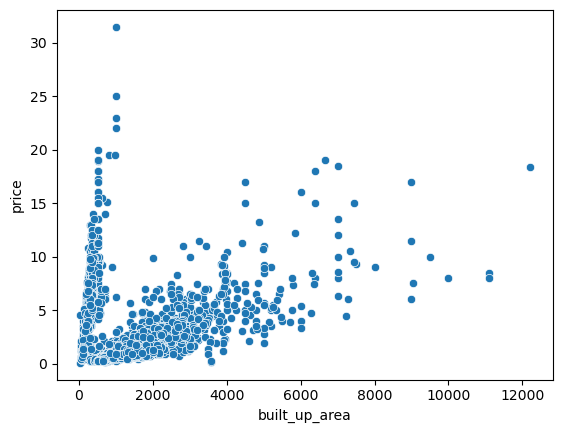

In [37]:
sns.scatterplot(x = df['built_up_area'],y = df['price'])

In [38]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [44]:
anamoly_df.sample(5)

,price,area,built_up_area
3423,2.57,1630.00,1811.0
2656,9.50,3593.84,400.0
2807,9.01,5605.96,521.0
2638,5.30,1936.80,215.0
2166,2.69,2152.00,1946.0


In [45]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [46]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

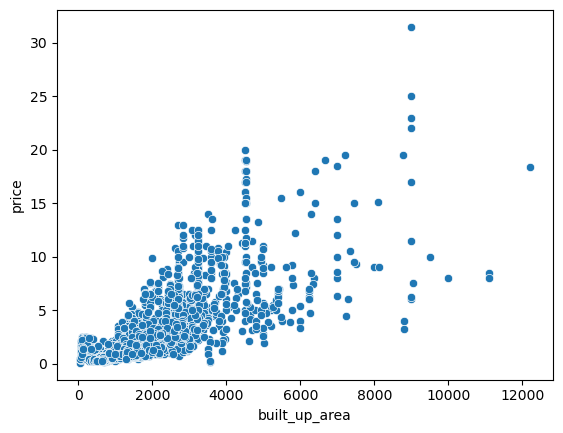

In [47]:
sns.scatterplot(x = df['built_up_area'],y = df['price'])

In [49]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area'],inplace=True)

In [50]:
df.isnull().sum()

property_name        0
type                 0
society            387
sector               0
price                0
price_per_sqft       0
bedRoom              0
bathroom             0
balcony              0
address              8
floorNum            15
facing               0
agePossession        0
description          0
built_up_area        0
study room           0
servant room         0
store room           0
pooja room           0
others               0
furnishing_type      0
luxury_score         0
dtype: int64

In [51]:
df[df['floorNum'].isnull()]

,property_name,type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,address,floorNum,facing,agePossession,description,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
114,4 Bedroom House for sale in Sector 26 Gurgaon,house,NaN,sector 26,4.60,12215.0,4,4,3,"F-5/10, Sector 26 Gurgaon, Gurgaon, Haryana",NaN,DK,Old Property,On the lookout for a spacious house in gurgaon...,3766.00,0,0,0,0,0,1,28
293,3 BHK Flat in Dwarka Expressway Gurgaon,flat,experion heartsong,dwarka expressway,1.08,6150.0,3,3,0,"604, Tower B-3, 6th Floor,Sector 108, Dwarka E...",NaN,DK,Under Construction,A property by one of the most reputed builders...,1758.00,0,0,0,0,0,1,0
687,2 BHK Flat in Sector 78 Gurgaon,flat,NaN,sector 78,0.60,3692.0,2,2,0,"Gurgaon, Sector 78 Gurgaon, Gurgaon, Haryana",NaN,DK,Under Construction,The property is under construction it's by rah...,1625.00,0,0,0,0,0,1,0
711,3 Bedroom House for sale in Ashok Vihar,house,NaN,sector 3,1.50,10326.0,3,3,0,"800 Lane 8 Ashok Vihar Part 1, Ashok Vihar, Gu...",NaN,DK,Old Property,Ground floor and partial first floor built up,210.00,0,0,0,0,0,1,0
734,3 Bedroom House for sale in New Colony,house,NaN,sector 7,6.50,15065.0,3,2,3,"New Colony, Gurgaon, Haryana",NaN,DK,Old Property,Old construction house in new colony gurgaon.,4314.76,0,0,0,0,0,1,9
1141,8 Bedroom House for sale in Palam Vihar,house,NaN,sector 2,5.60,17291.0,8,6,3,"Palam Vihar, Gurgaon, Haryana",NaN,South-West,Moderately Old,360 sq. Yards plot area near by global foyer m...,3238.76,1,1,1,1,0,1,0
1442,6 Bedroom House for sale in DLF Phase 2,house,NaN,sector 25,13.00,45764.0,6,8,3,"DLF Phase 2, Gurgaon, Haryana",NaN,DK,Relatively New,An impeccable opportunity is here for those wh...,2840.64,1,1,1,1,0,2,0
1677,4 Bedroom House for sale in Sector 48 Gurgaon,house,vipul tatvam villa,sector 48,8.50,26245.0,4,4,2,"Sector 48 Gurgaon, Gurgaon, Haryana",NaN,East,Moderately Old,Three side open villa in tatvam villa sector-4...,3238.76,0,1,1,1,0,1,88
2133,3 Bedroom House for sale in DLF Phase 3,house,NaN,sector 24,1.45,2995.0,3,3,1,"DLF Phase 3, Gurgaon, Haryana",NaN,DK,Old Property,Interested to sell independent house/villa.Pla...,60.00,0,0,0,0,0,1,9
2331,4 Bedroom House for sale in Sector 48 Gurgaon,house,vipul tatvam villa,sector 48,8.50,26245.0,4,4,1,"4 Bed And 4 Bathroom, Sector 48 Gurgaon, Gurga...",NaN,DK,Relatively New,360 sq yard 4 bhk residential villa for sale i...,3238.76,0,0,0,0,0,1,21


In [53]:
df[df['type'] == 'house']['floorNum'].median()

2.0

In [54]:
df['floorNum'].fillna(2.0,inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_26016\15612474.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0,inplace=True)


In [55]:
df.isnull().sum()

property_name        0
type                 0
society            387
sector               0
price                0
price_per_sqft       0
bedRoom              0
bathroom             0
balcony              0
address              8
floorNum             0
facing               0
agePossession        0
description          0
built_up_area        0
study room           0
servant room         0
store room           0
pooja room           0
others               0
furnishing_type      0
luxury_score         0
dtype: int64

In [56]:
df.drop(columns=['facing'],inplace=True)

In [57]:
df.isnull().sum()

property_name        0
type                 0
society            387
sector               0
price                0
price_per_sqft       0
bedRoom              0
bathroom             0
balcony              0
address              8
floorNum             0
agePossession        0
description          0
built_up_area        0
study room           0
servant room         0
store room           0
pooja room           0
others               0
furnishing_type      0
luxury_score         0
dtype: int64

In [58]:
df['agePossession'].value_counts()

agePossession
Relatively New        1592
New Property           553
Moderately Old         522
Undefined              414
Old Property           285
Under Construction     132
Name: count, dtype: int64

In [59]:

df[df['agePossession'] == 'Undefined']

,property_name,type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,address,floorNum,agePossession,description,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3,2 BHK Flat in Sector 36 Gurgaon,flat,signature global infinity mall,sector 36,0.41,6269.0,2,2,3,"Sohna Sector 36, Sector 36 Gurgaon, Gurgaon, H...",3.0,Undefined,Best in class property available at sector 36 ...,654.0,0,0,0,0,0,1,0
15,3 BHK Flat in Sector 77 Gurgaon,flat,umang winter hills,sector 77,1.40,6341.0,3,3,3,"H1004., Sector 77 Gurgaon, Gurgaon, Haryana",10.0,Undefined,3bhk multistorey apartment for resale in umang...,1735.0,0,0,0,0,0,1,28
27,3 BHK Flat in Sector 89 Gurgaon,flat,smart world gems,sector 89,1.25,8784.0,3,3,3,"Sector 89 Gurgaon, Gurgaon, Haryana",2.0,Undefined,It north facing house with open green garden a...,1288.0,0,0,0,1,0,1,12
28,2 BHK Flat in Sector 81 Gurgaon,flat,signature global city 81,sector 81,0.82,8641.0,2,2,3,"Sector 81, Sector 81 Gurgaon, Gurgaon, Haryana",2.0,Undefined,Best in class property available at sector 81 ...,955.0,0,0,0,0,0,1,53
31,3 BHK Flat in Sector 63A Gurgaon,flat,czar mahira homes 63a,sector 63a,0.42,7407.0,3,2,2,"Sector 63a, Sector 63A Gurgaon, Gurgaon, Haryana",0.0,Undefined,Best in class property available at sector 63a...,630.0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3425,2 BHK Flat in Sector 78 Gurgaon,flat,umang monsoon breeze,sector 78,0.70,5719.0,2,2,2,"Sector 78,gurgaon, Sector 78 Gurgaon, Gurgaon,...",5.0,Undefined,2bhk multistorey apartment for resale in umang...,1224.0,0,0,0,0,0,1,0
3432,3 BHK Flat in Sector 65 Gurgaon,flat,m3m heights,sector 65,2.86,13999.0,3,3,3,"Sector 65 Gurgaon, Gurgaon, Haryana",45.0,Undefined,East facing. Beautiful view from the top,2267.0,0,1,0,0,0,1,48
3438,3 BHK Flat in Sohna,flat,signature global park,sohna road,0.90,8036.0,3,2,0,"Sohna Sector 36, Sohna, Gurgaon, Haryana",2.0,Undefined,Best in class property available at sector 36 ...,1120.0,0,0,0,0,0,1,58
3453,2 BHK Flat in Sector 68 Gurgaon,flat,supertech hues,sector 68,0.93,8611.0,2,2,2,"Sector 68, Sector 68 Gurgaon, Gurgaon, Haryana",11.0,Undefined,Best in class property available at sector 68 ...,1200.0,0,0,0,0,0,1,0


In [62]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['type'] == row['type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [63]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [64]:
df['agePossession'].value_counts()

agePossession
Relatively New        1764
New Property           630
Moderately Old         561
Old Property           324
Under Construction     134
Undefined               85
Name: count, dtype: int64

In [65]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [66]:
df['agePossession'] = df.apply(mode_based_imputation2   ,axis=1)

In [67]:

df['agePossession'].value_counts()


agePossession
Relatively New        1779
New Property           650
Moderately Old         567
Old Property           334
Under Construction     134
Undefined               34
Name: count, dtype: int64

In [70]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['type'] == row['type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [71]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)
df['agePossession'].value_counts()

agePossession
Relatively New        1795
New Property           650
Moderately Old         585
Old Property           334
Under Construction     134
Name: count, dtype: int64

In [72]:
df.isnull().sum()

property_name        0
type                 0
society            387
sector               0
price                0
price_per_sqft       0
bedRoom              0
bathroom             0
balcony              0
address              8
floorNum             0
agePossession        0
description          0
built_up_area        0
study room           0
servant room         0
store room           0
pooja room           0
others               0
furnishing_type      0
luxury_score         0
dtype: int64

In [73]:
df.to_csv('data_gurgaon_properties_missing_value_imputation.csv',index=False)